# Exploratory Data Analysis

Use this notebook to explore distributions, relationships, missingness, and any patterns worth carrying forward into preprocessing or modeling.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

interim_dir = Path('../data/interim')

sns.set_theme(style='whitegrid')
df = pd.read_csv(interim_dir / 'joined_dataset.csv')

df.head()

,impression_id,user_id,product_id,platform,device_os,page_type,slot_position,hour_of_day,day_of_week,clicked,age,gender,city,product_name,brand,category,price_usd,discount_pct,avg_rating,review_count
0,1,6166,838,mobile_app,iOS,product_detail,1,6,Thu,0,41,F,Philadelphia,KitchenAid Compact Cordless Vacuum,KitchenAid,Home,602.95,7,4.2,385
1,2,840,807,mobile_app,Android,search,1,19,Wed,0,31,F,Dallas,Dyson Everyday Bedding Set,Dyson,Home,109.99,1,3.7,62
2,3,7780,884,mobile_app,iOS,category,2,0,Sun,0,39,M,Long Tail,The Golden Signal - Workbook,Simon & Schuster,Books,12.99,5,3.5,273
3,4,4422,307,website,Web,search,1,14,Sat,0,43,M,Philadelphia,Apple Tablet Plus,Apple,Electronics,174.99,2,4.4,94
4,5,3620,804,website,Web,product_detail,1,4,Mon,0,32,F,Charlotte,Nike Heritage Graphic Tee,Nike,Fashion,38.95,7,4.0,62


## Dataset Snapshot

Start with a quick look at the shape, types, and target balance.

In [12]:
print(f'Shape: {df.shape}')
display(df.dtypes)
display(df.describe(include='all').T)

click_rate = df['clicked'].mean()
print(f'Click rate: {click_rate:.4f}')

Shape: (450000, 20)


impression_id      int64
user_id            int64
product_id         int64
platform          object
device_os         object
page_type         object
slot_position      int64
hour_of_day        int64
day_of_week       object
clicked            int64
age                int64
gender            object
city              object
product_name      object
brand             object
category          object
price_usd        float64
discount_pct       int64
avg_rating       float64
review_count       int64
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
impression_id,450000.0,NaN,NaN,NaN,225000.5,129903.954905,1.0,112500.75,225000.5,337500.25,450000.0
user_id,450000.0,NaN,NaN,NaN,3998.740524,2309.471704,1.0,1995.0,4000.0,5996.0,8000.0
product_id,450000.0,NaN,NaN,NaN,598.495918,347.246624,1.0,298.0,596.0,899.0,1200.0
platform,450000,2,mobile_app,346756,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_os,450000,3,iOS,194564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
page_type,450000,4,home,148333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slot_position,450000.0,NaN,NaN,NaN,2.649398,1.532087,1.0,1.0,2.0,4.0,6.0
hour_of_day,450000.0,NaN,NaN,NaN,11.493636,6.928577,0.0,5.0,11.0,18.0,23.0
day_of_week,450000,7,Sat,67703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clicked,450000.0,NaN,NaN,NaN,0.06886,0.253216,0.0,0.0,0.0,0.0,1.0


Click rate: 0.0689


In [14]:
random_state = 42
target = 'clicked'
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=random_state,
    stratify=df[target],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=random_state,
    stratify=temp_df[target],
)

train_df.to_csv(processed_dir / 'train.csv', index=False)
val_df.to_csv(processed_dir / 'validation.csv', index=False)
test_df.to_csv(processed_dir / 'test.csv', index=False)

for name, split_df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f'{name}: shape={split_df.shape}, click_rate={split_df[target].mean():.4f}')


Train: shape=(315000, 20), click_rate=0.0689
Validation: shape=(67500, 20), click_rate=0.0689
Test: shape=(67500, 20), click_rate=0.0689


## Target Analysis: `clicked`

The target is binary, so check class imbalance first.

/var/folders/98/n_0mfbp91rxb8tfz32csh2jm0000gn/T/ipykernel_1061/704377937.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clicked_counts.index.astype(str), y=clicked_counts.values, ax=axes[0], palette='Blues')
/var/folders/98/n_0mfbp91rxb8tfz32csh2jm0000gn/T/ipykernel_1061/704377937.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clicked_rates.index.astype(str), y=clicked_rates.values, ax=axes[1], palette='Greens')


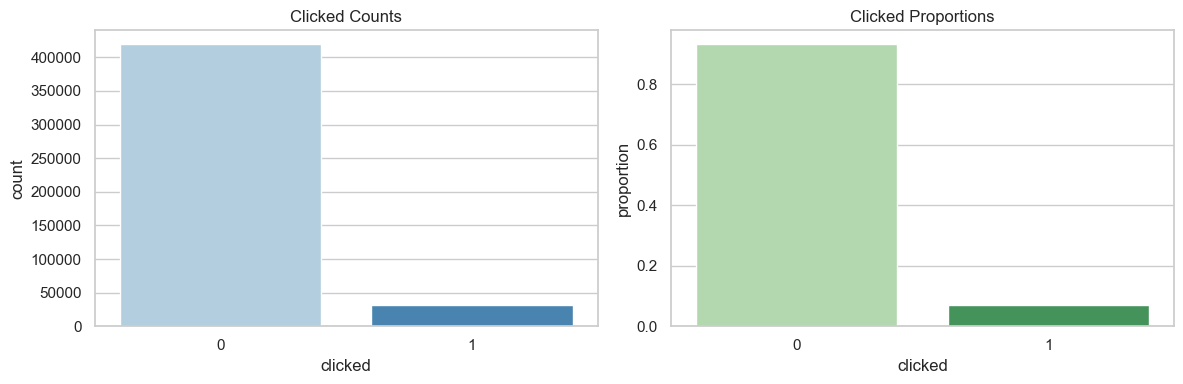

In [3]:
clicked_counts = df['clicked'].value_counts().sort_index()
clicked_rates = df['clicked'].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=clicked_counts.index.astype(str), y=clicked_counts.values, ax=axes[0], palette='Blues')
axes[0].set_title('Clicked Counts')
axes[0].set_xlabel('clicked')
axes[0].set_ylabel('count')

sns.barplot(x=clicked_rates.index.astype(str), y=clicked_rates.values, ax=axes[1], palette='Greens')
axes[1].set_title('Clicked Proportions')
axes[1].set_xlabel('clicked')
axes[1].set_ylabel('proportion')

plt.tight_layout()

In [4]:
display(clicked_counts.rename('count').to_frame())
display(clicked_rates.rename('proportion').to_frame())

,count
clicked,
0,419013
1,30987


,proportion
clicked,
0,0.93114
1,0.06886


## Univariate Analysis: `price_usd`

Inspect the distribution, spread, and possible outliers.

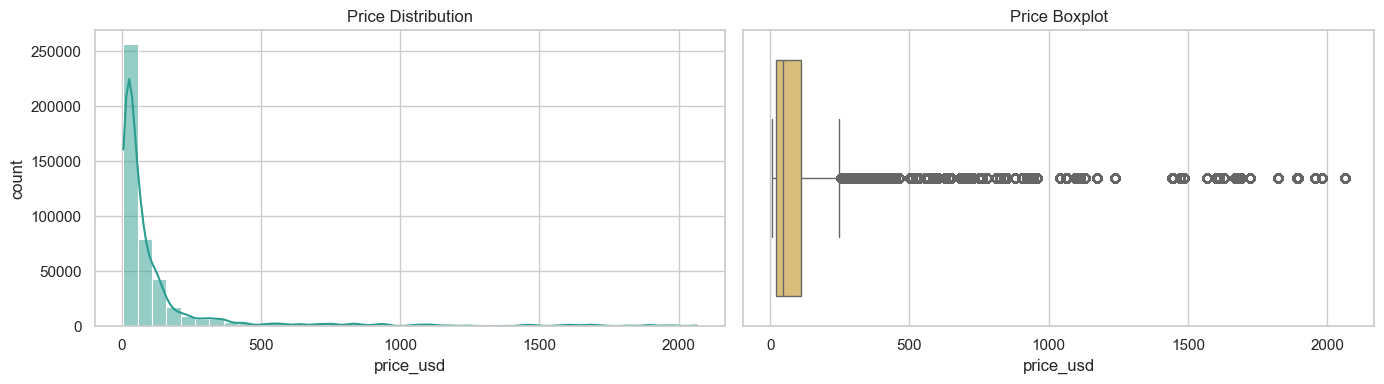

In [5]:
price = df['price_usd'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(price, bins=40, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('price_usd')
axes[0].set_ylabel('count')

sns.boxplot(x=price, ax=axes[1], color='#e9c46a')
axes[1].set_title('Price Boxplot')
axes[1].set_xlabel('price_usd')

plt.tight_layout()

In [6]:
price.describe().to_frame(name='price_usd')

,price_usd
count,450000.000000
mean,128.308521
std,261.507459
min,6.490000
25%,21.950000
50%,46.990000
75%,111.990000
max,2064.950000


## Bivariate Analysis

Compare click rate across selected categorical features.

/var/folders/98/n_0mfbp91rxb8tfz32csh2jm0000gn/T/ipykernel_1061/3825369656.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=platform_click, x='platform', y='clicked', ax=axes[0], palette='crest')
/var/folders/98/n_0mfbp91rxb8tfz32csh2jm0000gn/T/ipykernel_1061/3825369656.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=page_type_click, x='page_type', y='clicked', ax=axes[1], palette='magma')


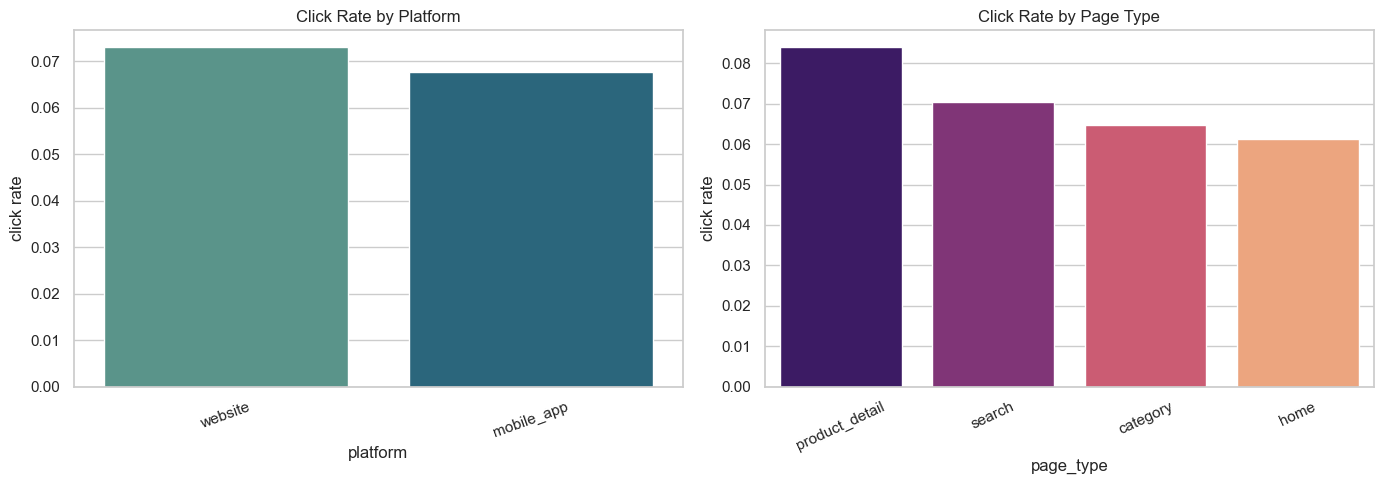

In [7]:
platform_click = (
    df.groupby('platform', as_index=False)['clicked']
      .mean()
      .sort_values('clicked', ascending=False)
)

page_type_click = (
    df.groupby('page_type', as_index=False)['clicked']
      .mean()
      .sort_values('clicked', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=platform_click, x='platform', y='clicked', ax=axes[0], palette='crest')
axes[0].set_title('Click Rate by Platform')
axes[0].set_xlabel('platform')
axes[0].set_ylabel('click rate')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=page_type_click, x='page_type', y='clicked', ax=axes[1], palette='magma')
axes[1].set_title('Click Rate by Page Type')
axes[1].set_xlabel('page_type')
axes[1].set_ylabel('click rate')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()

In [8]:
display(platform_click.assign(clicked=lambda x: x['clicked'].round(4)))
display(page_type_click.assign(clicked=lambda x: x['clicked'].round(4)))

,platform,clicked
1,website,0.0730
0,mobile_app,0.0676


,page_type,clicked
2,product_detail,0.0840
3,search,0.0704
0,category,0.0647
1,home,0.0614


## Multivariate Analysis

Use heatmaps to inspect interactions between multiple features and click rate.

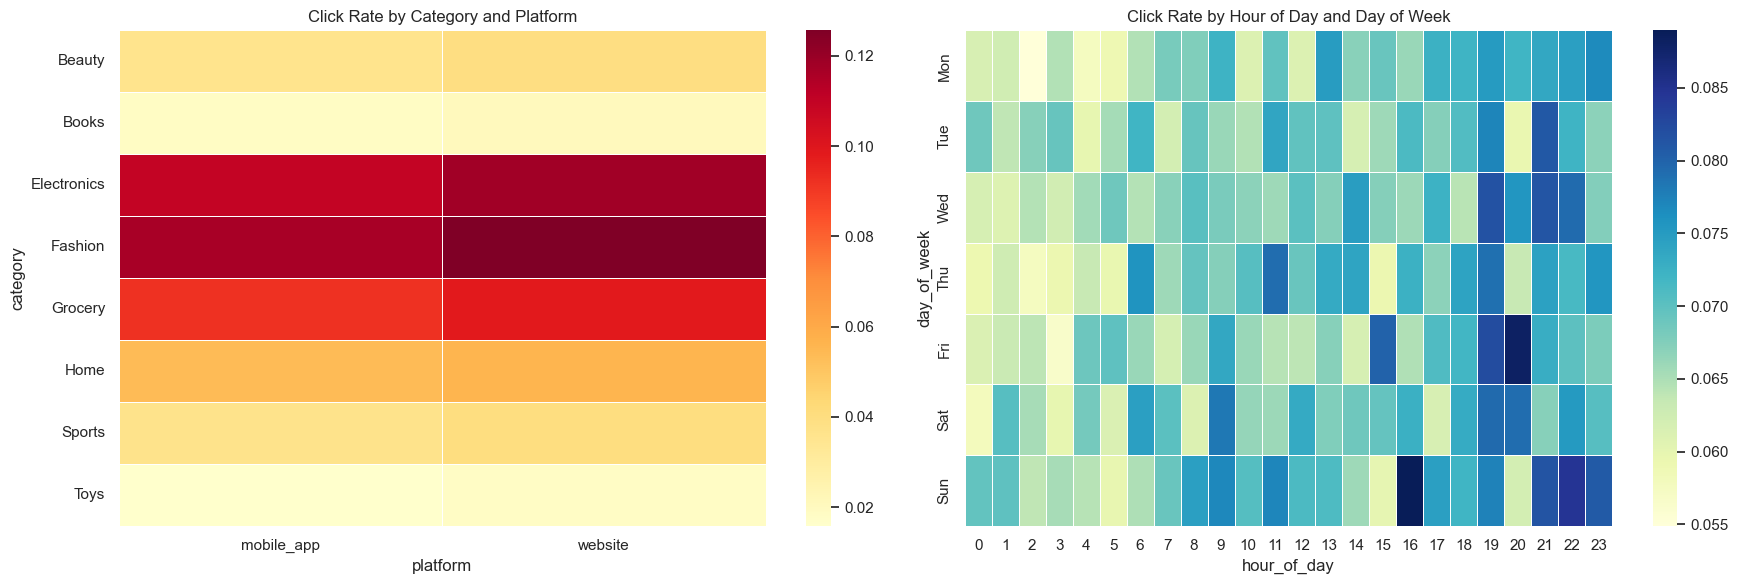

In [9]:
category_platform_click = pd.pivot_table(
    df,
    values='clicked',
    index='category',
    columns='platform',
    aggfunc='mean'
).sort_index()

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
hour_day_click = pd.pivot_table(
    df,
    values='clicked',
    index='day_of_week',
    columns='hour_of_day',
    aggfunc='mean'
).reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(category_platform_click, ax=axes[0], cmap='YlOrRd', annot=False, linewidths=0.5)
axes[0].set_title('Click Rate by Category and Platform')
axes[0].set_xlabel('platform')
axes[0].set_ylabel('category')

sns.heatmap(hour_day_click, ax=axes[1], cmap='YlGnBu', annot=False, linewidths=0.5)
axes[1].set_title('Click Rate by Hour of Day and Day of Week')
axes[1].set_xlabel('hour_of_day')
axes[1].set_ylabel('day_of_week')

plt.tight_layout()

In [ ]:
display(category_platform_click.round(4))
display(hour_day_click.round(4))